# Exploratory Data Analysis on the Titanic Dataset

In [30]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
#load dataset
d=pd.read_csv('train.csv')

In [3]:
#check shape of dataset
d.shape

(891, 12)

In [4]:
#check info of dataset
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
d=d.set_index('PassengerId')

In [6]:
d_dict=pd.DataFrame(d.dtypes)
d_dict

,0
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


In [7]:
d_dict=d_dict.rename(columns={0:'dtype'})
d_dict

,dtype
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64
Cabin,object


In [8]:
d_dict['Total']=d.count()
d_dict

,dtype,Total
Survived,int64,891
Pclass,int64,891
Name,object,891
Sex,object,891
Age,float64,714
SibSp,int64,891
Parch,int64,891
Ticket,object,891
Fare,float64,891
Cabin,object,204


In [9]:
d_dict['Missing']=d.isnull().sum()
d_dict

,dtype,Total,Missing
Survived,int64,891,0
Pclass,int64,891,0
Name,object,891,0
Sex,object,891,0
Age,float64,714,177
SibSp,int64,891,0
Parch,int64,891,0
Ticket,object,891,0
Fare,float64,891,0
Cabin,object,204,687


In [10]:
d_dict['Unique']=d.nunique()
d_dict

,dtype,Total,Missing,Unique
Survived,int64,891,0,2
Pclass,int64,891,0,3
Name,object,891,0,891
Sex,object,891,0,2
Age,float64,714,177,88
SibSp,int64,891,0,7
Parch,int64,891,0,7
Ticket,object,891,0,681
Fare,float64,891,0,248
Cabin,object,204,687,147


In [11]:
d=d.drop(['Cabin'],axis=1)

In [12]:
d.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
d.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


38% of passenegers were survived and 62% of passengers were not survived

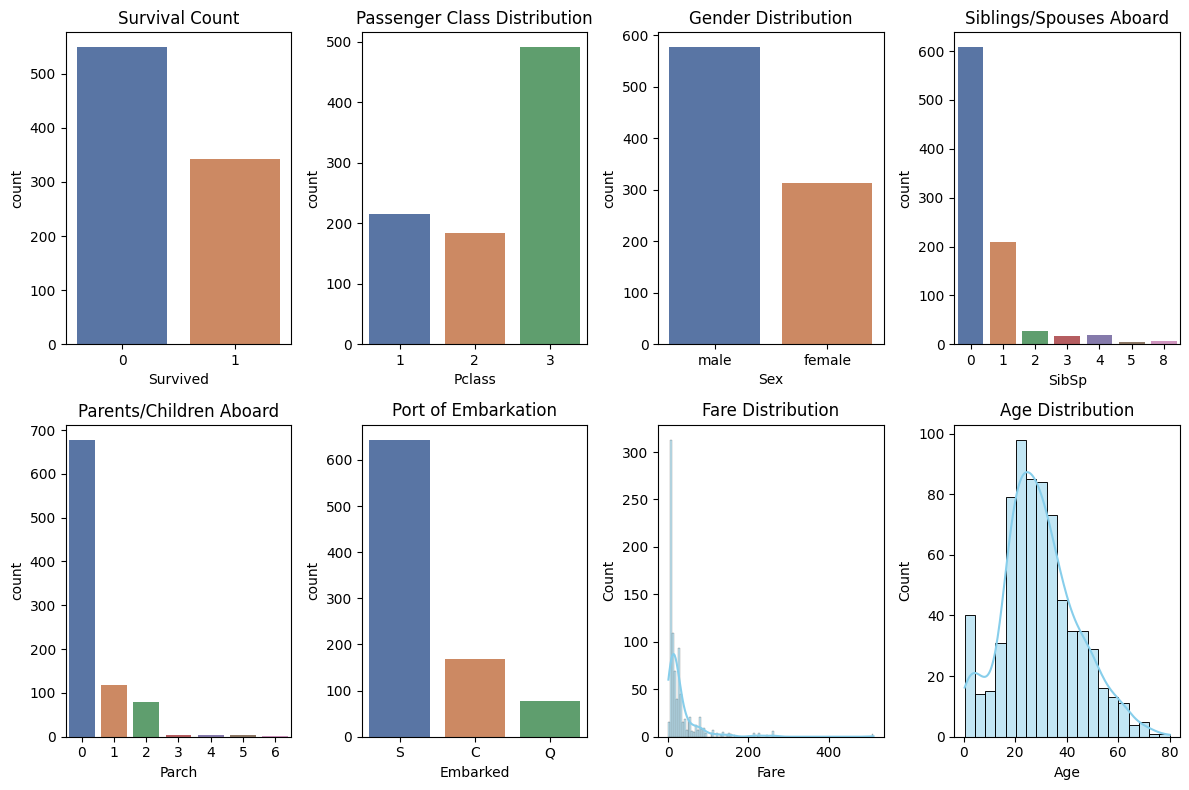

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(12, 8))

sns.countplot(x='Survived', data=d, ax=axes[0, 0], palette='deep')
axes[0, 0].set_title('Survival Count')

sns.countplot(x='Pclass', data=d, ax=axes[0, 1], palette='deep')
axes[0, 1].set_title('Passenger Class Distribution')

sns.countplot(x='Sex', data=d, ax=axes[0, 2], palette='deep')
axes[0, 2].set_title('Gender Distribution')

sns.countplot(x='SibSp', data=d, ax=axes[0, 3], palette='deep')
axes[0, 3].set_title('Siblings/Spouses Aboard')

# Second row - more categorical + numeric distributions
sns.countplot(x='Parch', data=d, ax=axes[1, 0], palette='deep')
axes[1, 0].set_title('Parents/Children Aboard')

sns.countplot(x='Embarked', data=d, ax=axes[1, 1], palette='deep')
axes[1, 1].set_title('Port of Embarkation')

sns.histplot(d['Fare'], kde=True, ax=axes[1, 2], color='skyblue')
axes[1, 2].set_title('Fare Distribution')

sns.histplot(d['Age'].dropna(), kde=True, ax=axes[1, 3], color='skyblue')
axes[1, 3].set_title('Age Distribution')

# Tight layout for clear spacing
plt.tight_layout()
plt.show()


In [15]:
d['Name_len']=d.Name.str.len()

In [16]:
d['Ticket_First']=d.Ticket.str[0]
d['FamilyCount']=d.SibSp+d.Parch

In [17]:
d['title'] = d.Name.str.extract('\, ([A-Z][^ ]*\.)',expand=False)

In [18]:
d.title.value_counts()

,count
title,
Mr.,517
Miss.,182
Mrs.,125
Master.,40
Dr.,7
Rev.,6
Mlle.,2
Major.,2
Col.,2


In [19]:
d.head(1)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Name_len,Ticket_First,FamilyCount,title
PassengerId,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,S,23,A,1,Mr.


In [20]:
print(f'Age column have {d.Age.isnull().sum()} null values')
print(f'Embarked column have {d.Embarked.isnull().sum()} null values')

Age column have 177 null values
Embarked column have 2 null values


In [21]:
d.Age=d.Age.replace(np.nan,d.Age.mean())
d.Embarked=d.Embarked.replace(np.nan,d.Embarked.mode()[0])

In [22]:
d.drop(['Name','Ticket','SibSp','Parch'],axis=1,inplace=True)

In [23]:
d.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Name_len',
       'Ticket_First', 'FamilyCount', 'title'],
      dtype='object')

In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
d['Sex'] = le.fit_transform(d['Sex'])  # male=1, female=0
d = pd.get_dummies(d, columns=['Embarked', 'Ticket_First', 'title'], drop_first=True)

In [27]:
x=d.drop(['Survived'],axis=1)
y=d.Survived

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [31]:
folds=KFold(n_splits=5)

In [45]:
M1=LogisticRegression()
M2=RandomForestClassifier()
M3=GradientBoostingClassifier()

In [46]:
score1=cross_val_score(M1,x_train,y_train,cv=folds)
score2=cross_val_score(M2,x_train,y_train,cv=folds)
score3=cross_val_score(M3,x_train,y_train,cv=folds)

In [47]:
print(f'Logistic Regression Score: {score1.mean()}')
print(f'Random Forest Score: {score2.mean()}')
print(f'Gradient Boosting Score: {score3.mean()}')

Logistic Regression Score: 0.8300305328474342
Random Forest Score: 0.8272628779671034
Gradient Boosting Score: 0.8229685807150597


Without splitting

In [49]:
x=d.drop(['Survived'],axis=1)
y=d.Survived

In [50]:
M4=LogisticRegression()
M5=RandomForestClassifier()
M6=GradientBoostingClassifier()

In [52]:
M4.fit(x,y)

LogisticRegression()

In [53]:
M5.fit(x,y)

RandomForestClassifier()

In [55]:
M6.fit(x,y)

GradientBoostingClassifier()

In [56]:
print(f'Logistic Regression Score: {M4.score(x,y)}')
print(f'Random Forest Score: {M5.score(x,y)}')
print(f'Gradient Boosting Score: {M6.score(x,y)}')

Logistic Regression Score: 0.8327721661054994
Random Forest Score: 0.9977553310886644
Gradient Boosting Score: 0.9023569023569024
